## Model Explainability
The explainability analysis will cover:

- Global feature importance
- Direction and magnitude of feature impact
- SHAP summary visualization
- Individual applicant explanations
- High-risk and low-risk prediction analysis
- Business interpretation of model behavior

##  Explainability Objectives

The primary objectives of this analysis are:

1. Identify the most influential features used by the model.
2. Understand whether each feature increases or decreases default risk.
3. Explain individual applicant predictions.
4. Identify characteristics associated with higher default risk.
5. Improve the transparency and interpretability of the credit-risk model.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

print("Libraries imported successfully.")

Libraries imported successfully.


### Load Final optimized XGboost model

In [2]:
model = joblib.load("../models/xgboost_model.pkl")

print("Model loaded successfully.")
print("Model type:", type(model))

Model loaded successfully.
Model type: <class 'xgboost.sklearn.XGBClassifier'>


### Load Processed Test Data
- The test data contains the final transformed feature representation
used by the XGBoost model.

In [3]:
# Load processed test data

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

# Convert target DataFrame to Series
y_test = y_test.squeeze()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (51070, 24)
y_test shape: (51070,)


### Processed Features

In [4]:
# Display processed feature names

feature_names = X_test.columns.tolist()

print("Number of Features:", len(feature_names))

print("\nProcessed Features:")
for i, feature in enumerate(feature_names, start=1):
    print(f"{i}. {feature}")

Number of Features: 24

Processed Features:
1. Age
2. Income
3. LoanAmount
4. CreditScore
5. MonthsEmployed
6. NumCreditLines
7. InterestRate
8. LoanTerm
9. DTIRatio
10. Education_High School
11. Education_Master's
12. Education_PhD
13. EmploymentType_Part-time
14. EmploymentType_Self-employed
15. EmploymentType_Unemployed
16. MaritalStatus_Married
17. MaritalStatus_Single
18. HasMortgage_Yes
19. HasDependents_Yes
20. LoanPurpose_Business
21. LoanPurpose_Education
22. LoanPurpose_Home
23. LoanPurpose_Other
24. HasCoSigner_Yes


In [5]:
# Verify that model and test data have matching feature dimensions

print("Model expected features:", model.n_features_in_)
print("Test dataset features:", X_test.shape[1])

if model.n_features_in_ == X_test.shape[1]:
    print("\n Feature dimensions match.")
else:
    print("\n Feature dimension mismatch.")

Model expected features: 24
Test dataset features: 24

 Feature dimensions match.


## SHAP Explainability

SHAP (SHapley Additive exPlanations) is used to interpret the predictions
of the optimized XGBoost model.

SHAP assigns each feature a contribution value that indicates how strongly
that feature influenced a prediction.

Positive SHAP values generally push the prediction toward the Default
class, while negative values push the prediction toward the Non-Default
class.

In [6]:
import sys
import numpy
import numba
import llvmlite

print("Python   :", sys.version)
print("NumPy    :", numpy.__version__)
print("Numba    :", numba.__version__)
print("llvmlite :", llvmlite.__version__)

Python   : 3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)]
NumPy    : 2.4.6
Numba    : 0.66.0
llvmlite : 0.48.0


In [7]:
import shap

print("SHAP:", shap.__version__)

c:\Users\littt\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP: 0.52.0


##  Create SHAP Tree Explainer

Because the final model is an XGBoost tree-based model, SHAP's
TreeExplainer is used to efficiently calculate feature contributions.

To make the analysis computationally efficient, a representative sample
of the test dataset is used for the global explainability analysis.

In [8]:
# Create SHAP TreeExplainer

explainer = shap.TreeExplainer(model)

print("SHAP TreeExplainer created successfully.")

SHAP TreeExplainer created successfully.


In [11]:
# Create sample data for SHAP

shap_sample = X_test.iloc[:100]

print("SHAP sample created successfully.")
print("SHAP sample shape:", shap_sample.shape)

SHAP sample created successfully.
SHAP sample shape: (100, 24)


## Calculate SHAP Values

SHAP values quantify the contribution of each feature to the model's
prediction.

These values will be used to identify the most influential factors in
the model's default-risk predictions.

In [12]:
# Calculate SHAP values

shap_values = explainer.shap_values(shap_sample)

print("SHAP values calculated successfully.")
print("SHAP values shape:", np.array(shap_values).shape)

SHAP values calculated successfully.
SHAP values shape: (100, 24)


### Global Feature Importance 

Global feature importance identifies the features that have the greatest
overall influence on the model's predictions.


In [13]:
# Calculate mean absolute SHAP importance

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_ABS_SHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values("Mean_ABS_SHAP", ascending=False)
    .reset_index(drop=True)
)

shap_importance

,Feature,Mean_ABS_SHAP
0,Age,0.580918
1,InterestRate,0.449855
2,MonthsEmployed,0.317886
3,Income,0.303003
4,LoanAmount,0.274641
5,HasCoSigner_Yes,0.122843
6,HasDependents_Yes,0.120735
7,CreditScore,0.110865
8,NumCreditLines,0.104120
9,EmploymentType_Unemployed,0.101946


### Top Features by SHAP Importance

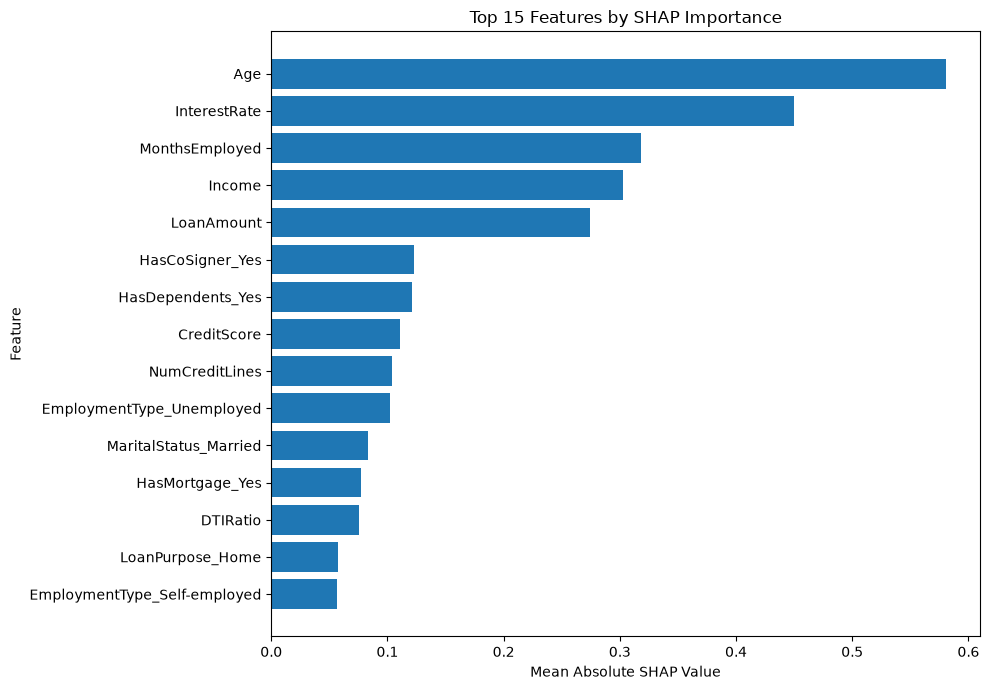

In [14]:
# Plot top 15 features

top_features = shap_importance.head(15).sort_values(
    "Mean_ABS_SHAP",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Mean_ABS_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")

plt.title(
    "Top 15 Features by SHAP Importance"
)

plt.tight_layout()
plt.show()

## SHAP Summary Plot

The SHAP summary plot shows both the importance and direction of feature
effects on model predictions.

Each point represents an observation.

- Positive SHAP values push predictions toward the Default class.
- Negative SHAP values push predictions toward the Non-Default class.
- Color represents the feature value.
- Higher feature values are generally shown in red.
- Lower feature values are generally shown in blue.

This allows us to understand not only which features matter, but also
how different feature values influence default-risk predictions.

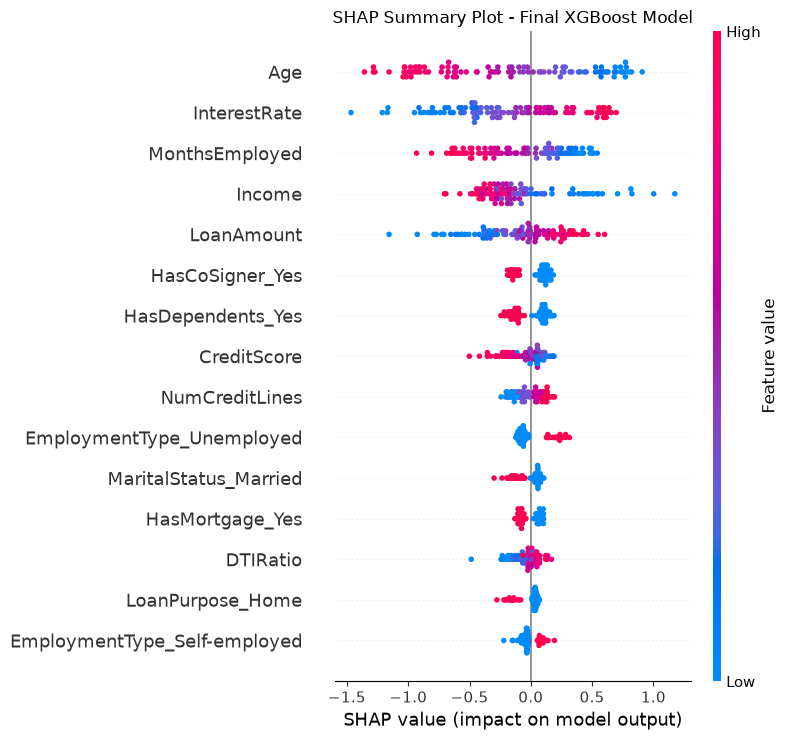

In [15]:
# SHAP summary / beeswarm plot

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    shap_sample,
    feature_names=feature_names,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Summary Plot - Final XGBoost Model"
)

plt.tight_layout()
plt.show()

## SHAP Dependence Analysis

SHAP dependence plots show how individual feature values influence
the model's prediction.

They help identify whether higher or lower values of an important
feature increase or decrease predicted loan-default risk.

### Age

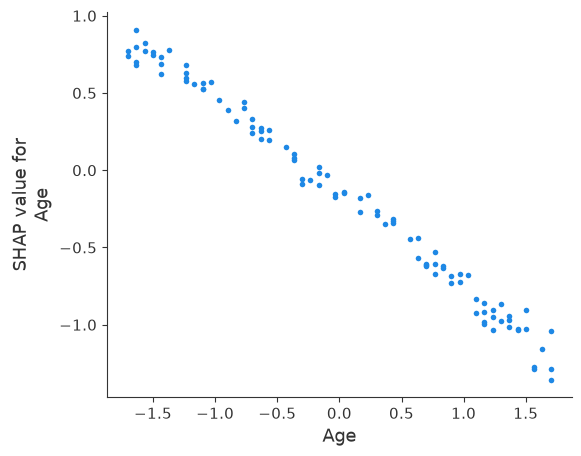

In [16]:
shap.dependence_plot(
    "Age",
    shap_values,
    shap_sample,
    interaction_index=None
)

Age increases
      ↓
SHAP value decreases
      ↓
Lower predicted default risk

### Intrest Rate

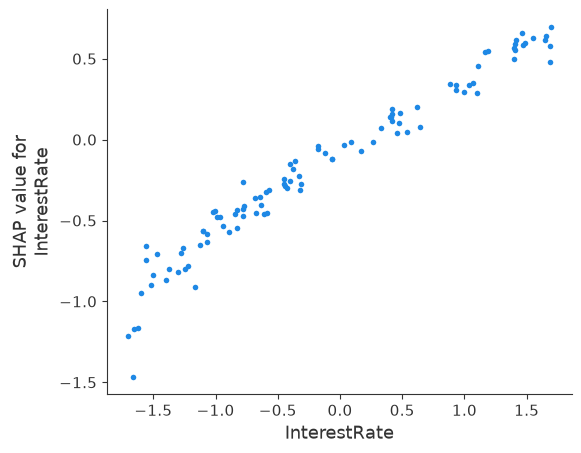

In [17]:
shap.dependence_plot(
    "InterestRate",
    shap_values,
    shap_sample,
    interaction_index=None
)

InterestRate increases
        ↓
SHAP value increases
        ↓
Higher predicted default risk

### Months Employed

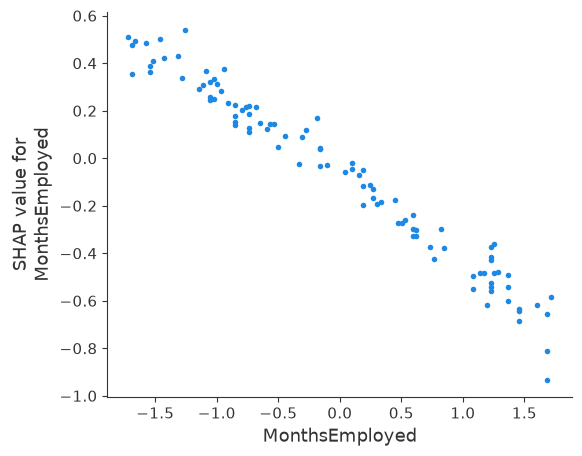

In [18]:
shap.dependence_plot(
    "MonthsEmployed",
    shap_values,
    shap_sample,
    interaction_index=None
)

MonthsEmployed increases
        ↓
SHAP value decreases
        ↓
Lower predicted default risk

### Income

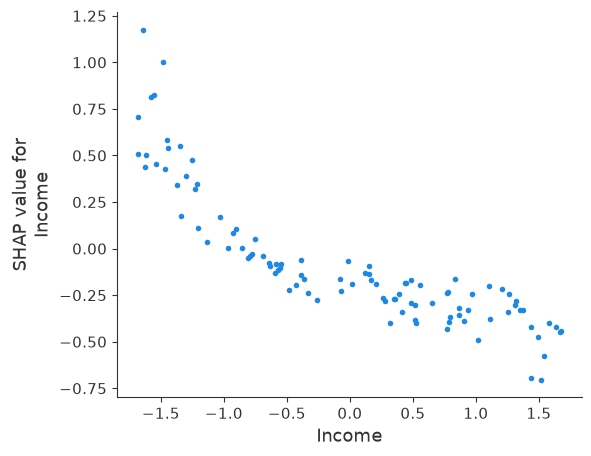

In [19]:
shap.dependence_plot(
    "Income",
    shap_values,
    shap_sample,
    interaction_index=None
)

Income increases
      ↓
SHAP value decreases
      ↓
Lower predicted default risk

### Loan Amount

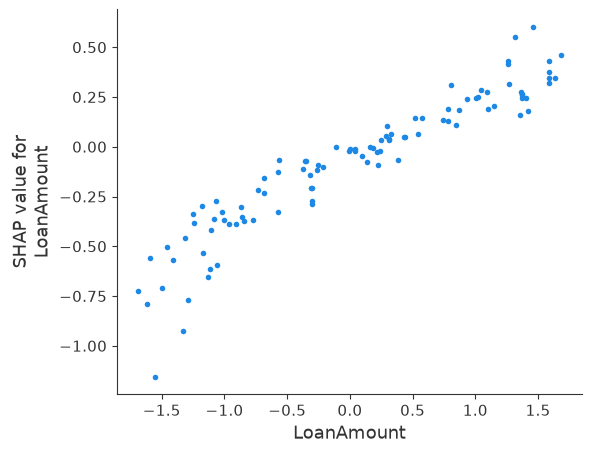

In [20]:
shap.dependence_plot(
    "LoanAmount",
    shap_values,
    shap_sample,
    interaction_index=None
)

LoanAmount increases
       ↓
SHAP value increases
       ↓
Higher predicted default risk

## Individual Applicant Explanation

SHAP values can also be used to explain individual predictions.

For a selected applicant, we identify the features that contribute
toward Default and the features that contribute toward Non-Default.

In [21]:
# Select one applicant from the SHAP sample

applicant_index = 0

applicant = shap_sample.iloc[applicant_index]

print("Selected Applicant:")
print(applicant)

Selected Applicant:
Age                             0.700569
Income                         -1.579535
LoanAmount                     -0.570617
CreditScore                     1.351358
MonthsEmployed                  1.225576
NumCreditLines                  1.341937
InterestRate                   -0.678493
LoanTerm                       -0.708685
DTIRatio                        0.648668
Education_High School              False
Education_Master's                  True
Education_PhD                      False
EmploymentType_Part-time           False
EmploymentType_Self-employed       False
EmploymentType_Unemployed          False
MaritalStatus_Married              False
MaritalStatus_Single                True
HasMortgage_Yes                     True
HasDependents_Yes                   True
LoanPurpose_Business               False
LoanPurpose_Education               True
LoanPurpose_Home                   False
LoanPurpose_Other                  False
HasCoSigner_Yes                    Fa

In [24]:
final_threshold = joblib.load("../models/threshold.pkl")

print("Loaded Final Threshold:", final_threshold)

Loaded Final Threshold: 0.5699999999999997


In [23]:
# Get the selected applicant's model prediction
# Final threshold selected during model optimization
final_threshold = 0.57
applicant_data = shap_sample.iloc[[applicant_index]]

applicant_probability = model.predict_proba(applicant_data)[0, 1]

applicant_prediction = int(
    applicant_probability >= final_threshold
)

print("Applicant Default Probability:", round(applicant_probability, 4))
print("Final Threshold:", final_threshold)
print("Predicted Class:", applicant_prediction)

if applicant_prediction == 1:
    print("Prediction: DEFAULT")
else:
    print("Prediction: NON-DEFAULT")

Applicant Default Probability: 0.2223
Final Threshold: 0.57
Predicted Class: 0
Prediction: NON-DEFAULT


##  Individual Applicant SHAP Explanation

SHAP values explain how each feature contributed to the selected
applicant's prediction.

Positive SHAP values push the prediction toward Default, while
negative SHAP values push the prediction toward Non-Default.

In [25]:
# Get SHAP values for the selected applicant

applicant_shap = shap_values[applicant_index]

individual_explanation = pd.DataFrame({
    "Feature": feature_names,
    "Feature_Value": shap_sample.iloc[applicant_index].values,
    "SHAP_Value": applicant_shap
})

# Sort by absolute SHAP contribution
individual_explanation["Absolute_SHAP"] = (
    individual_explanation["SHAP_Value"].abs()
)

individual_explanation = (
    individual_explanation
    .sort_values("Absolute_SHAP", ascending=False)
    .reset_index(drop=True)
)

individual_explanation.head(10)

,Feature,Feature_Value,SHAP_Value,Absolute_SHAP
0,Income,-1.579535,0.816156,0.816156
1,Age,0.700569,-0.614180,0.614180
2,InterestRate,-0.678493,-0.455820,0.455820
3,MonthsEmployed,1.225576,-0.427091,0.427091
4,LoanAmount,-0.570617,-0.329895,0.329895
5,CreditScore,1.351358,-0.193877,0.193877
6,NumCreditLines,1.341937,0.192941,0.192941
7,HasMortgage_Yes,True,-0.103651,0.103651
8,HasDependents_Yes,True,-0.103064,0.103064
9,HasCoSigner_Yes,False,0.092416,0.092416


"For this applicant, Age and Income pushed the prediction toward Non-Default, while some other factors pushed it toward Default."

## Individual SHAP Waterfall Plot

The SHAP waterfall plot visualizes how each feature moves the selected
applicant's prediction away from the model's baseline prediction.

Features pushing toward Default and Non-Default can therefore be
identified visually.

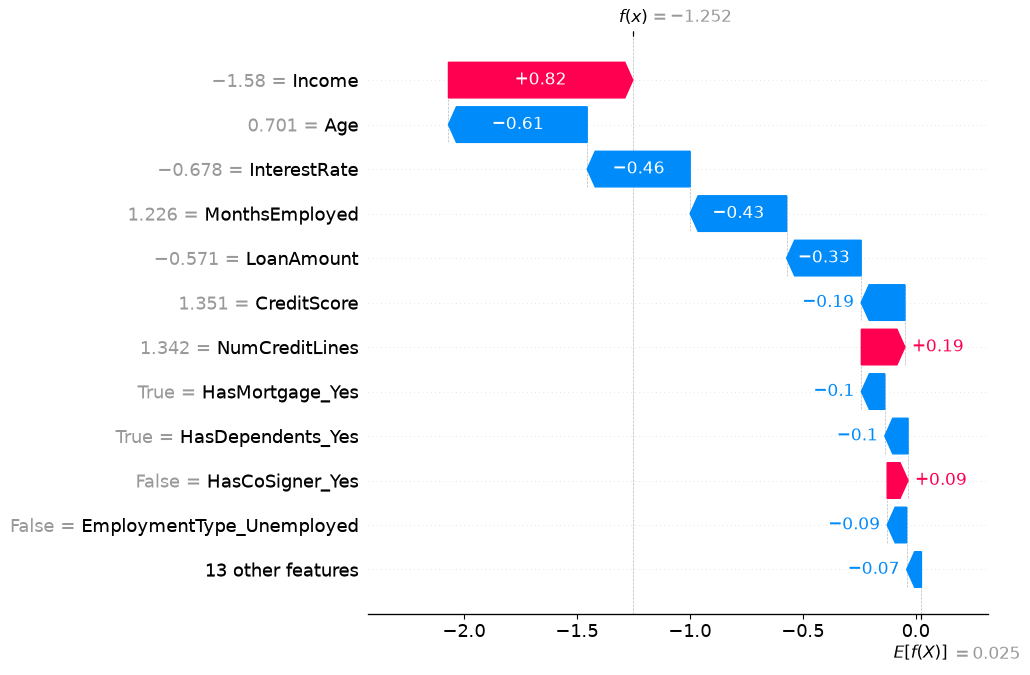

In [26]:
# Create SHAP explanation object for the selected applicant

applicant_explanation = shap.Explanation(
    values=applicant_shap,
    base_values=explainer.expected_value,
    data=shap_sample.iloc[applicant_index].values,
    feature_names=feature_names
)

shap.plots.waterfall(
    applicant_explanation,
    max_display=12
)

## High-Risk Applicant Explanation

To demonstrate how the model explains high-risk cases, we identify an
applicant with a high predicted probability of loan default.

The SHAP explanation will show which features contribute most strongly
to the increased default risk.

In [27]:
# Calculate default probabilities for the SHAP sample

sample_probabilities = model.predict_proba(shap_sample)[:, 1]

# Find the applicant with the highest predicted default probability

high_risk_index = np.argmax(sample_probabilities)

high_risk_probability = sample_probabilities[high_risk_index]

print("High-Risk Applicant Index:", high_risk_index)
print("Default Probability:", round(high_risk_probability, 4))

High-Risk Applicant Index: 36
Default Probability: 0.9154


In [28]:
# Display high-risk applicant's features

high_risk_applicant = shap_sample.iloc[high_risk_index]

print("High-Risk Applicant:")
print(high_risk_applicant)

High-Risk Applicant:
Age                            -0.099952
Income                         -1.553073
LoanAmount                      1.314644
CreditScore                     0.231182
MonthsEmployed                 -1.545521
NumCreditLines                 -0.448549
InterestRate                    1.416006
LoanTerm                       -1.415845
DTIRatio                       -0.650505
Education_High School               True
Education_Master's                 False
Education_PhD                      False
EmploymentType_Part-time           False
EmploymentType_Self-employed        True
EmploymentType_Unemployed          False
MaritalStatus_Married               True
MaritalStatus_Single               False
HasMortgage_Yes                     True
HasDependents_Yes                  False
LoanPurpose_Business               False
LoanPurpose_Education               True
LoanPurpose_Home                   False
LoanPurpose_Other                  False
HasCoSigner_Yes                    F

## 💼 Final Business Insights

SHAP analysis provides interpretable insights into the factors influencing
the final XGBoost loan-default predictions.

### Key Findings

- Age is the most influential feature in the final model.
- Interest Rate is the second most influential feature, with higher values
  generally increasing predicted default risk.
- Longer employment duration generally reduces predicted default risk.
- Higher income generally pushes predictions toward lower default risk,
  while lower income can increase predicted default risk.
- Larger loan amounts generally increase predicted default risk.
- Credit Score contributes to the model's risk assessment, although its
  overall SHAP importance is lower than the top five features.
- Applicant characteristics such as co-signer status, dependents,
  mortgage status, and employment type also contribute to predictions,
  but with comparatively lower overall influence.

Overall, SHAP analysis improves model transparency by showing both the
global importance of features and their contribution to individual
applicant predictions.

In [29]:
# Create reports directory

os.makedirs("../reports", exist_ok=True)

# Save global SHAP feature importance
shap_importance.to_csv(
    "../reports/shap_feature_importance.csv",
    index=False
)

# Save individual applicant explanation
individual_explanation.to_csv(
    "../reports/individual_shap_explanation.csv",
    index=False
)

print("SHAP analysis reports saved successfully.")

SHAP analysis reports saved successfully.


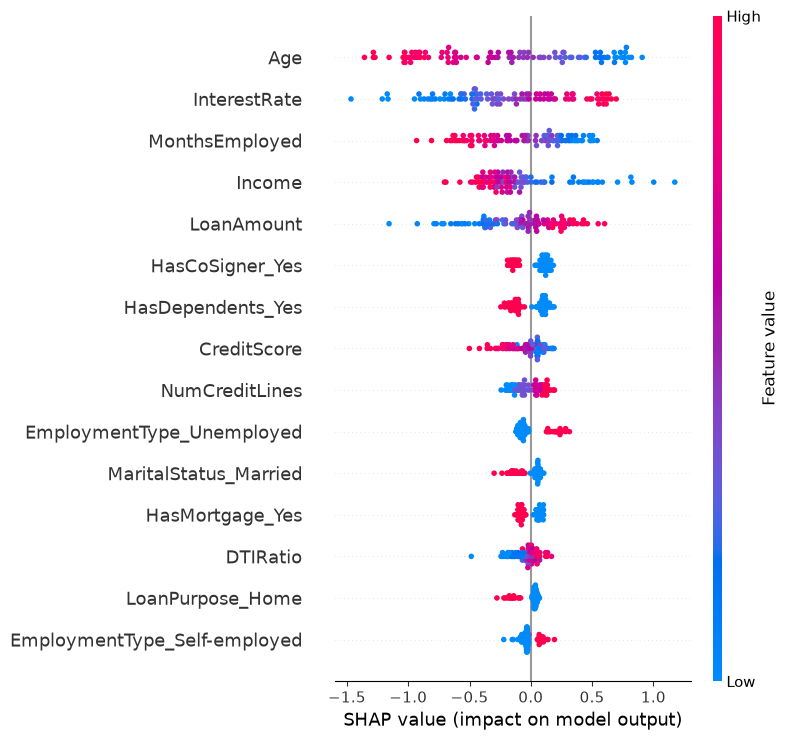

SHAP summary plot saved successfully.


In [30]:
plt.figure()

shap.summary_plot(
    shap_values,
    shap_sample,
    feature_names=feature_names,
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../reports/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP summary plot saved successfully.")

Final interpretation

Your model's most influential features are:

Age
InterestRate
MonthsEmployed
Income
LoanAmount
HasCoSigner
HasDependents
CreditScore